# tspropy Plotting Tutorial

This tutorial introduces the plotting capabilities of **tspropy** for datetime-indexed time-series data. In
df_interpoltor_tutorial.ipynb and basic_processing_tutorial.ipynb, further practical examples about tspropy-plotters
 use cases.

The plotting layer is designed to make common time-series visualization tasks concise and configurable, while still providing the flexibility needed for more advanced analysis. The examples below progress from basic plotting to multiple axes, highlighted time ranges, vertical markers, styling, and comparison plots.

# 1. Plotters

## 1.1 Overview

Visualization is an important part of time-series analysis. A time series can contain trends, recurring patterns, operational states, and exceptional events that are difficult to identify from tabular data alone.

The `tspropy` plotting layer provides reusable functions for visualizing datetime-indexed pandas DataFrames. It is built around **Plotly**, giving the resulting figures interactive features such as zooming, panning, and hover information.

The plotting functions are intended to cover both simple exploratory plots and more structured visualizations. In particular, they support configuration of axes, curve appearance, highlighted periods, event markers, and other figure properties.

The main plotting function introduced in this tutorial is `plot_datetime_data`.

## 1.2 `plot_datetime_data`

`plot_datetime_data` is the primary entry point for plotting datetime-indexed tabular data in `tspropy`.

Its basic usage is deliberately simple: provide a pandas DataFrame with a `DatetimeIndex`, and the function creates an interactive time-series figure. At the same time, the function exposes configuration options for progressively more advanced visualizations.

Among its capabilities are:

- plotting multiple time-series curves,
- assigning curves to up to three independent Y-axes,
- configuring Y-axis limits and labels,
- controlling curve colours, line styles, and widths,
- highlighting built-in calendar ranges such as weekends and public holidays,
- highlighting arbitrary custom time ranges,
- highlighting periods defined by boolean masks,
- adding vertical lines at selected timestamps,
- and customizing fonts and other visual properties.

This combination is particularly useful for operational and energy time series, where variables often have different units and where events or operating periods need to be interpreted directly in the context of the data.

# 2. Dataset

## 2.1 Energy time-series example

The examples use `load_and_price.csv`, a compact energy dataset covering **one week**, from **28 December 2017 to 3 January 2018**.

The dataset is **at 5-minute intervals** and four time-series variables:

| Column | Description | Unit |
| --- | --- | --- |
| `Day-Ahead Price` | Day-ahead electricity market price | €/MWh |
| `PV Generation` | Photovoltaic generation | MW |
| `Total Site Load` | Total electrical demand of the site | MW |
| `Grid Load` | Electrical demand supplied by the grid | MW |

The dataset is deliberately small enough to keep the examples lightweight while still containing several useful patterns:

- daily load profiles,
- PV generation during daylight hours,
- the relationship between PV generation and grid load,
- different load behaviour during the weekend and New Year's Day,
- and electricity prices changing independently from the load curves.

The timestamp index is timezone-aware and uses UTC. The day-ahead price is repeated for the three 5-minute observations belonging to each 15-minute market interval.

This makes the dataset a useful example for demonstrating how several time-series signals with different characteristics can be visualized together.

## 2.2 Load the dataset

The dataset is stored in `examples/data/load_and_price.csv`.

We load the `datetime` column as the index and select the three load-related variables for the first plotting examples.

In [5]:
import pandas as pd

from src.data_manipulation.custom_objects.location import Location
from src.data_manipulation.custom_objects.plotter_objects import (
    Axes,
    BuiltinRange,
    Color,
    ColorMapper,
    CustomRange,
    FontSizes,
    Labels,
    LineStyles,
    LineWidths,
    MaskRange,
    RangeConfig,
    RangePropertyName,
    StyleName,
    VLineConfig,
    VLinePropertyName,
    YLimits,
)
from src.plotters.plotly_plotters import plot_datetime_comparison, plot_datetime_data

df = pd.read_csv(
    r"../data/load_and_price.csv",
    index_col="datetime",
    parse_dates=True,
)

loads_cols = ["Total Site Load", "Grid Load", "PV Generation"]
loads_df = df[loads_cols]

# 3. Basic plotting

## 3.1 Plotting all selected columns on one axis

The simplest use case is to pass a DataFrame directly to `plot_datetime_data`.

All selected columns are plotted on the primary Y-axis. By default, the plotter also provides a legend, the X-axis label `"Time"`, and grid lines.

In [ ]:
fig1 = plot_datetime_data(df=loads_df)


> *Basic time-series plot with Total Site Load, Grid Load, and PV Generation on one Y-axis.*

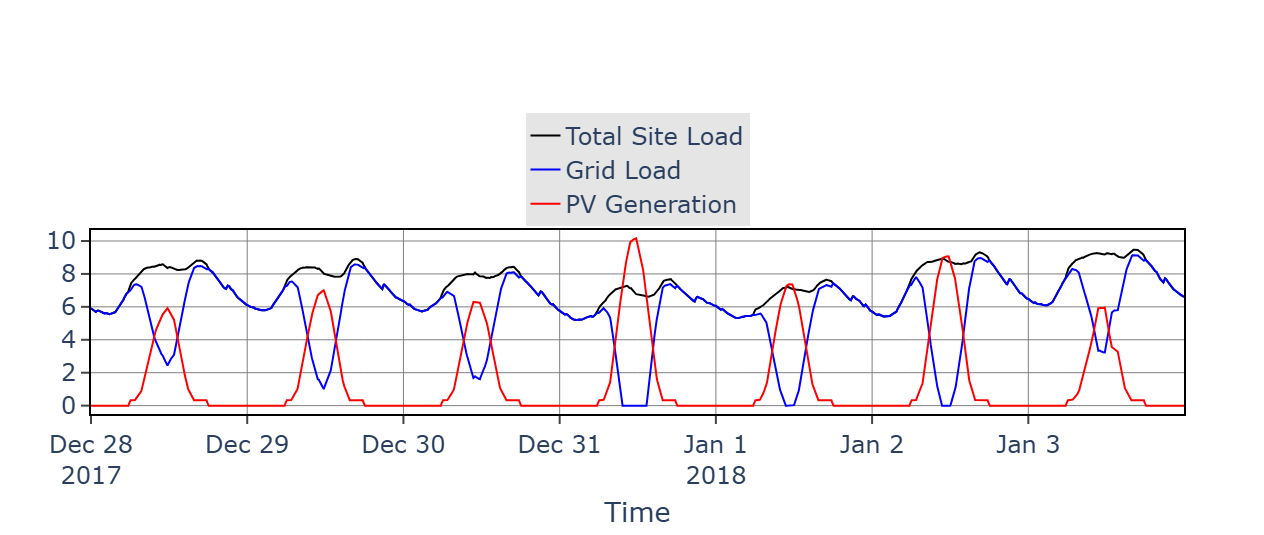

The basic figure already provides an interactive overview of the three signals. The next examples show how the same plotting function can be configured when the default appearance is not sufficient.

## 3.2 Specifying Y-axis limits and curve colours

The displayed Y-axis range can be controlled with `YLimits`.

Individual curves can also be assigned explicit colours using `ColorMapper`. Curves that are not explicitly mapped continue to use the plotter's default colour selection.

In [6]:
fig2 = plot_datetime_data(
    df=loads_df,
    y_limits=YLimits(y1_limit=[-1, 15]),
    color_mapper=[
        ColorMapper(curve_name="Grid Load", color=Color.BLUE),
        ColorMapper(curve_name="PV Generation", color=Color.ORANGE),
        # "Total Site Load" is not specified -> a default color is selected.
    ],
)

> *The same three load curves with a specified Y-axis range and explicit colors for Grid Load and PV Generation.*
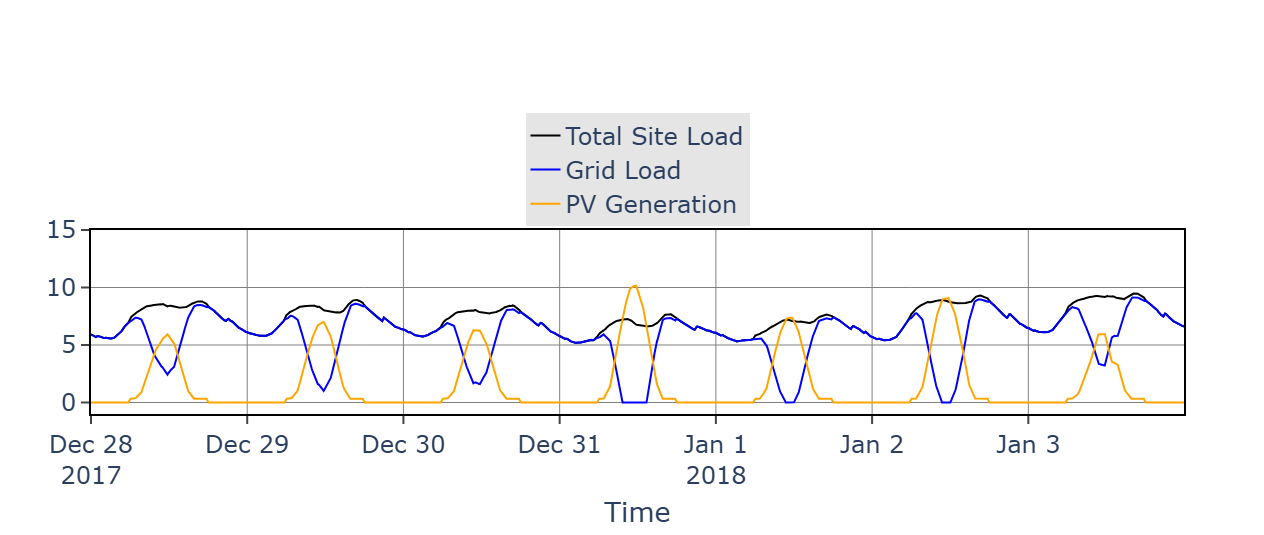

## 3.3 Plotting curves on different Y-axes

Different variables often have different units or numerical ranges. Plotting them on one axis can make one signal difficult to interpret.

`plot_datetime_data` supports up to **three independent Y-axes**. The `Axes` configuration determines which curves are assigned to each axis.

By default, curves on Y1 use a solid line style, curves on Y2 use a dashed line style, and curves on Y3 use a dashed-dotted line style. This provides a visual distinction between curves belonging to different axes.

Here, the load-related curves are assigned to Y1 and the day-ahead price is assigned to Y2.

Aside the axes-specification, this example shows how to specify the title and labels, too.

In [10]:
fig3 = plot_datetime_data(
    df=df,
    axes=Axes(
        y1=loads_cols,
        y2="Day-Ahead Price",  # ["Day-Ahead Price"] works, too.
    ),
    title="Load and Price Data",
    labels=Labels(
        y1_label="Load in MW",
        y2_label="Price in €/MW",
    ),
)

> *Load curves on the first Y-axis and Day-Ahead Price on a second independent Y-axis, with a title and axis labels.*
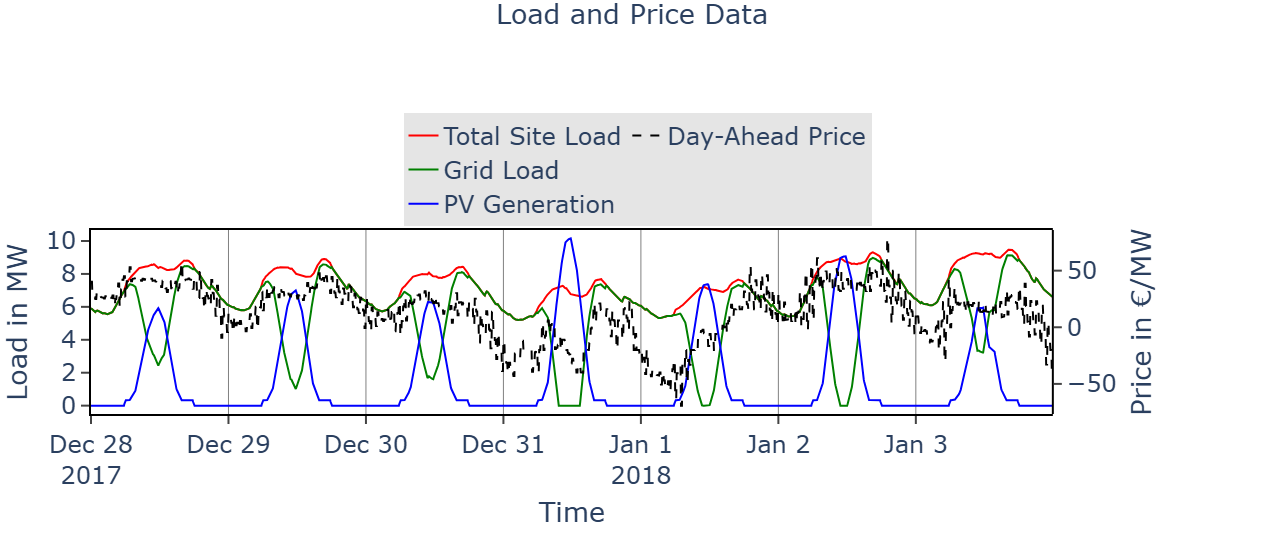

# 4. Advanced plotting features

## 4.1 Highlighted ranges

Time-series plots often become much easier to interpret when important periods are highlighted directly on the chart.

`plot_datetime_data` supports three types of highlighted ranges:

1. **Built-in ranges** — predefined calendar-based ranges such as weekends and public holidays.
2. **Custom ranges** — explicitly specified start and end timestamps.
3. **Mask ranges** — periods determined by a boolean pandas mask.

These range types can also be combined in a single figure.

### 4.1.1 Built-in ranges

The total site load on 30 and 31 December 2017 and on 1 January 2018 is noticeably lower than on the other days.

Highlighting the weekend and public holiday helps provide context for this behaviour. The lower consumption can then be interpreted in relation to the operating calendar rather than being treated simply as an unexplained change in the time series.

For public holidays, a `Location` is required so that the plotter can determine the appropriate holiday calendar.

In [11]:
fig4 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    range_config=[
        RangeConfig(
            range_type=BuiltinRange.WEEKENDS,  # Default color is gray
        ),
        RangeConfig(
            range_type=BuiltinRange.HOLIDAYS,
            property={RangePropertyName.COLOR: Color.CYAN},
            # Location is a mandatory input when range_type is BuiltinRange.HOLIDAYS
            location=Location(country_code="DE"),
        ),
    ],
)

> *Load time series with weekends and German public holidays highlighted.*
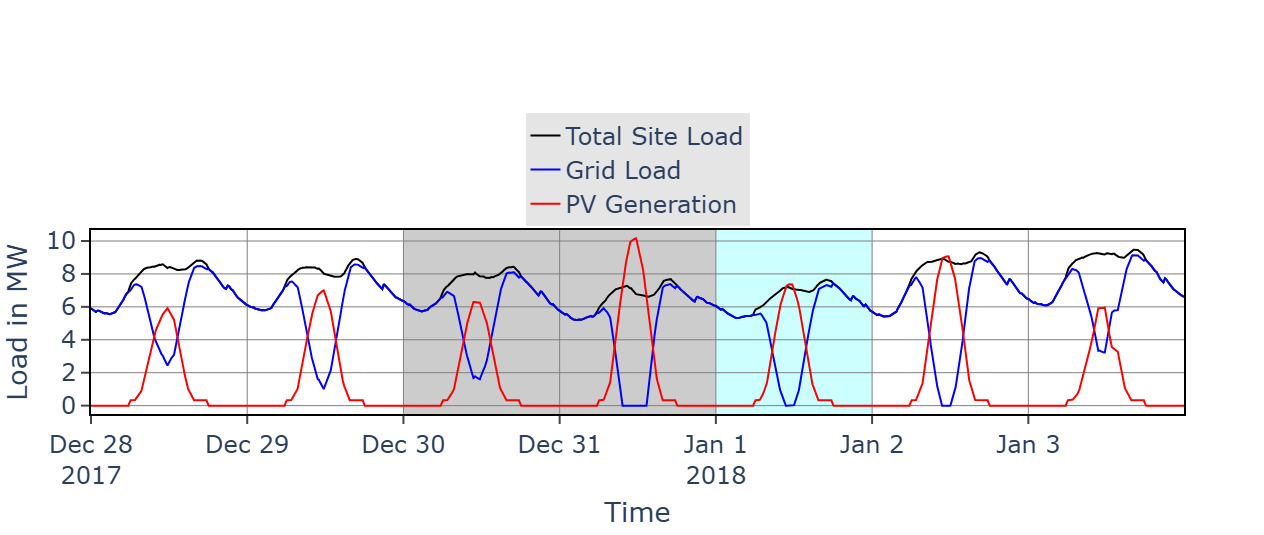

### 4.1.2 Custom ranges

Not every period of interest can be described by a calendar rule. `CustomRange` can be used when a specific start and end timestamp should be highlighted.

The following example highlights a six-hour period on 30 December. In a real application, such a range could represent a maintenance period, an operational event, a test, or another period whose behaviour deserves closer attention.

In [ ]:
fig5 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    range_config=RangeConfig(
        range_type=CustomRange(
            range=["2017-12-30 12:00", "2017-12-30 18:00"],
        ),
        property={RangePropertyName.COLOR: Color.CORAL},
    ),
)

> *Load time series with a custom six-hour period highlighted.*
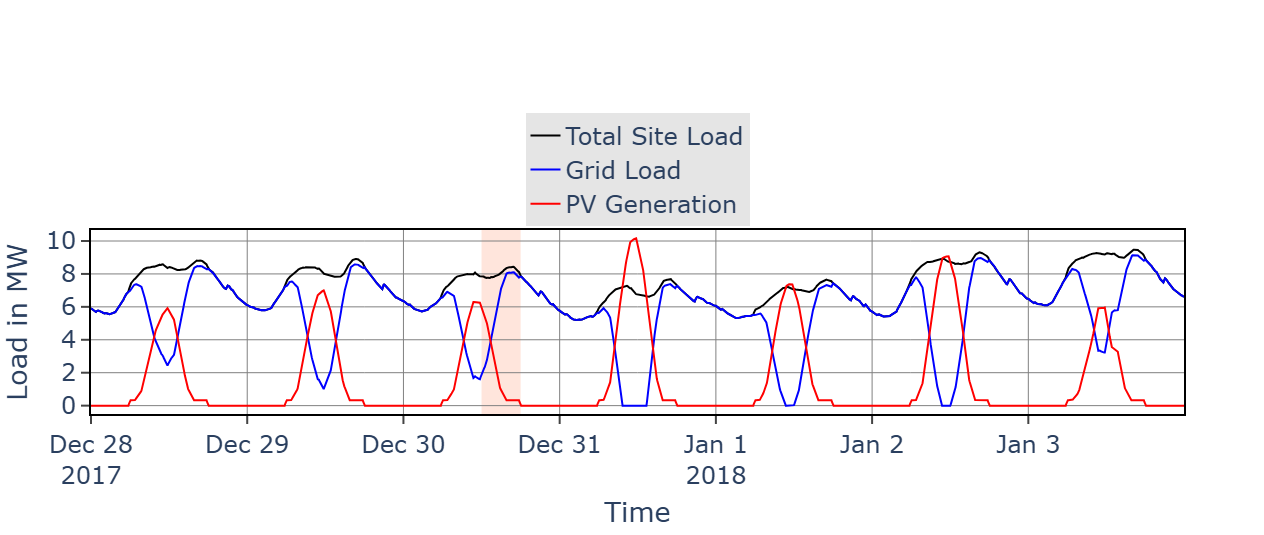

### 4.1.3 Mask ranges

A range can also be defined by the data itself.

A boolean mask is useful when the periods to highlight are determined by a condition rather than by fixed timestamps. In this example, periods where `Grid Load` is zero are interpreted as PV-surplus phases and highlighted in orange.

In [ ]:
mask_of_pv_surplus_phases = loads_df["Grid Load"] == 0

fig6 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    range_config=RangeConfig(
        range_type=MaskRange(range=mask_of_pv_surplus_phases),
        property={RangePropertyName.COLOR: Color.ORANGE},
    ),
)

> *PV-surplus phases identified by a boolean mask and highlighted in orange.*
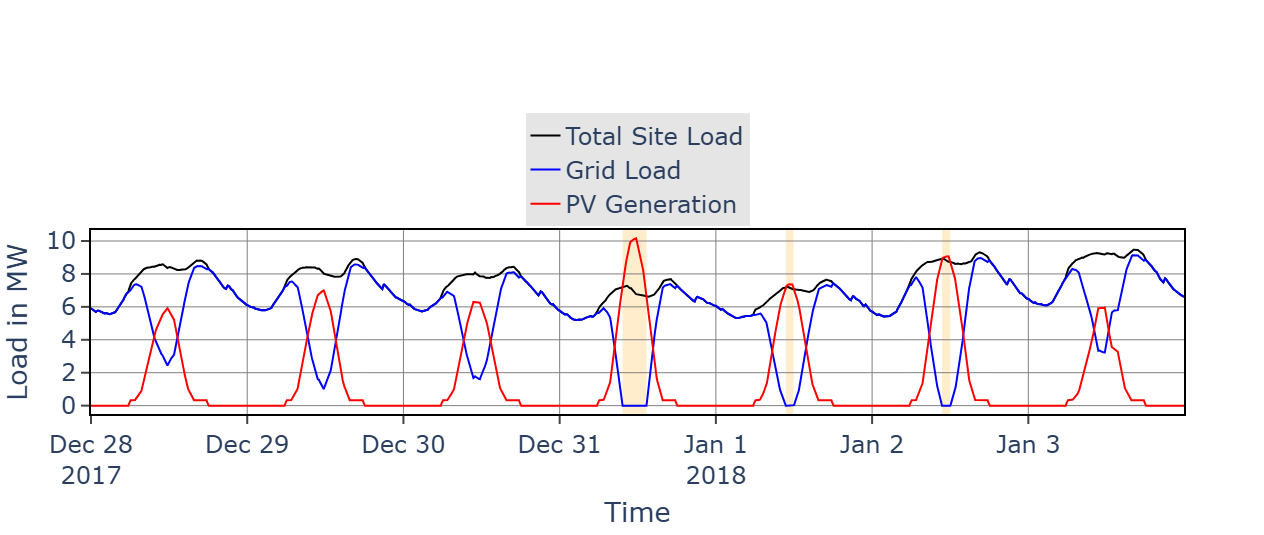

### 4.1.4 Combining different range types

Different range definitions can be combined on the same plot.

Here, data-driven PV-surplus phases and calendar-based weekends are highlighted simultaneously. This illustrates how contextual information and information derived directly from the data can be layered onto one visualization.

In [ ]:
fig7 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    range_config=[
        RangeConfig(
            range_type=MaskRange(range=mask_of_pv_surplus_phases),
            property={RangePropertyName.COLOR: Color.ORANGE},
        ),
        RangeConfig(
            range_type=BuiltinRange.WEEKENDS,  # Default color is gray
        ),
    ],
)

> *A combined visualization with PV-surplus phases and weekends highlighted using different range definitions.*
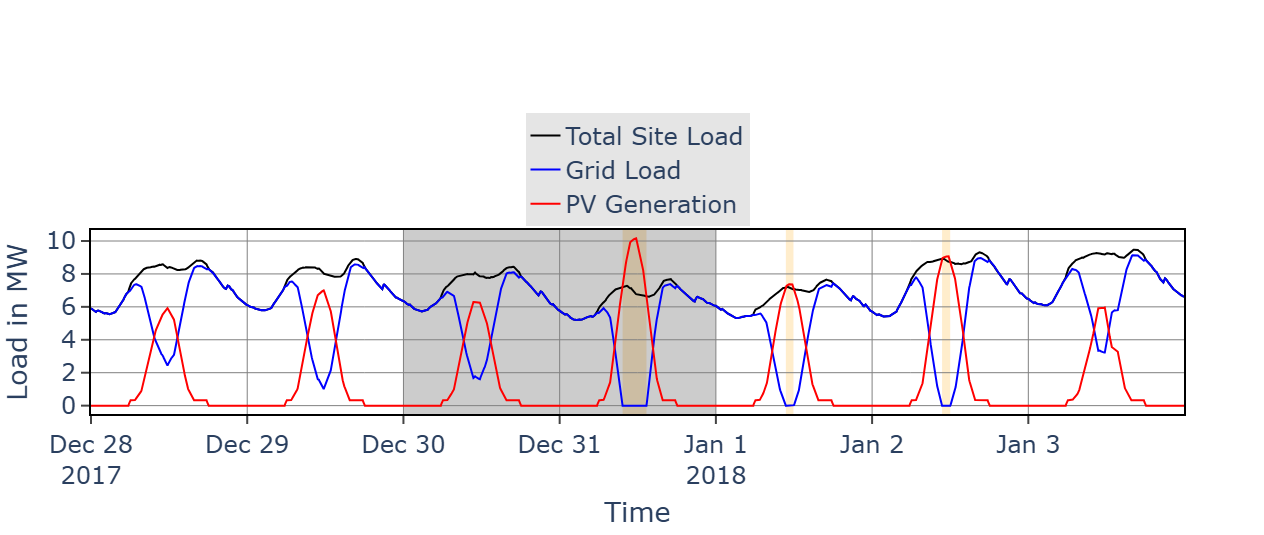

## 4.2 Vertical lines

Vertical lines can be used to emphasize specific timestamps or to divide a plot into regular time intervals.

In the following example, vertical lines are placed every 12 hours. The grid is disabled to make the vertical markers easier to distinguish.

In [14]:
fig8 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    v_line_config=VLineConfig(
        position=loads_df.index.floor("12h").unique(),
        property={
            VLinePropertyName.COLOR: Color.BLACK,
            VLinePropertyName.WIDTH: 1,
        },
    ),
    show_grid=False,
)

> *Load time series divided by vertical markers at 12-hour intervals.*
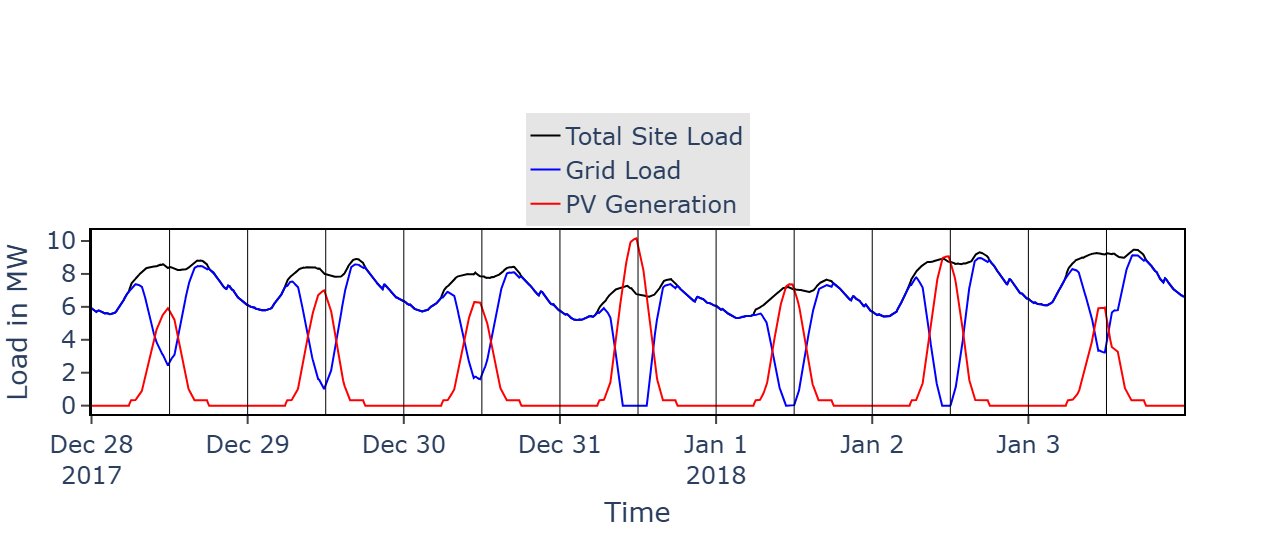

# 5. Secondary features

## 5.1 Customizing the appearance

In addition to controlling the data and contextual elements shown on a plot, `plot_datetime_data` provides secondary features for customizing the appearance and behaviour of the resulting figure.

For example, line styles, line widths, and font sizes can be configured independently.

In [ ]:
fig9 = plot_datetime_data(
    df=loads_df,
    labels=Labels(y1_label="Load in MW"),
    line_styles=LineStyles(line_style1=StyleName.DASH),
    line_widths=LineWidths(line_width1=3),
    font_sizes=FontSizes(legend_fs=15),
)

> *Customized line style, line width, and legend font size.*
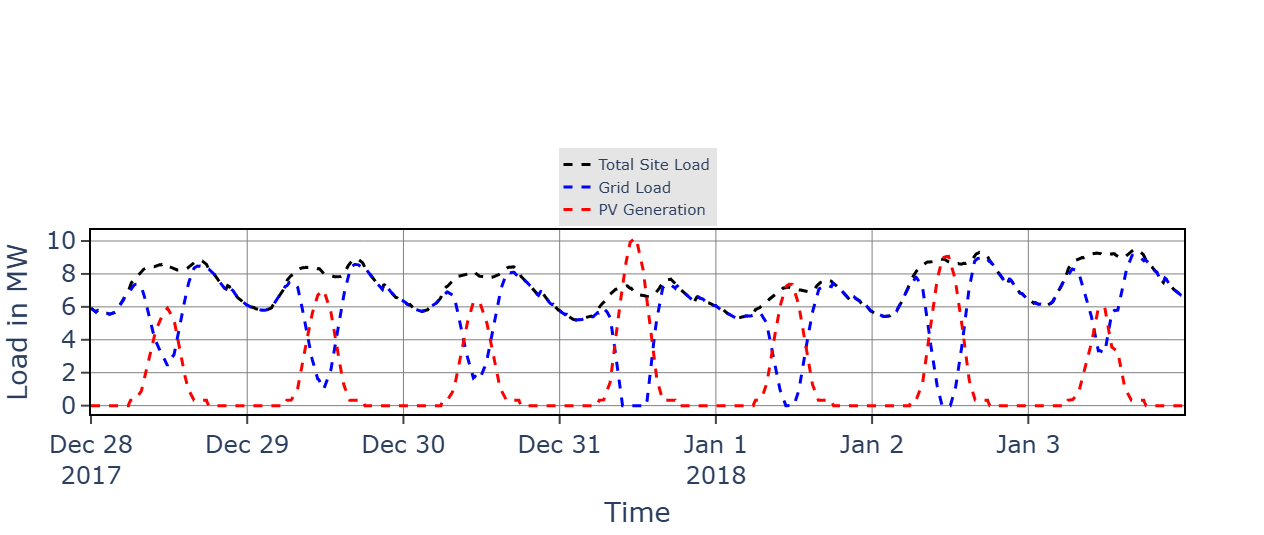

# 6. `plot_datetime_comparison`

## 6.1 Comparing filtered and complete time-series data

`plot_datetime_comparison` is built on top of `plot_datetime_data`.

It accepts a complete DataFrame and a filtered DataFrame. The observations contained in the filtered DataFrame are emphasized using darker colours, while the remaining observations are displayed using lighter colours.

This is useful when a subset of the data needs to be examined in the context of the complete time series. For example, the subset could represent high-load periods, detected anomalies, a specific operating state, or observations selected by another analysis step.

The comparison plotter accepts the configuration parameters available to `plot_datetime_data`, such as `labels`, `axes`, and `color_mapper`.

In [ ]:
mask_high_site_loads = loads_df["Total Site Load"] > 8  # MW

fig10 = plot_datetime_comparison(
    df=loads_df,
    filtered_df=loads_df[mask_high_site_loads],
)

> *Complete load time series shown in lighter colours with periods above 8 MW emphasized in darker colours.*
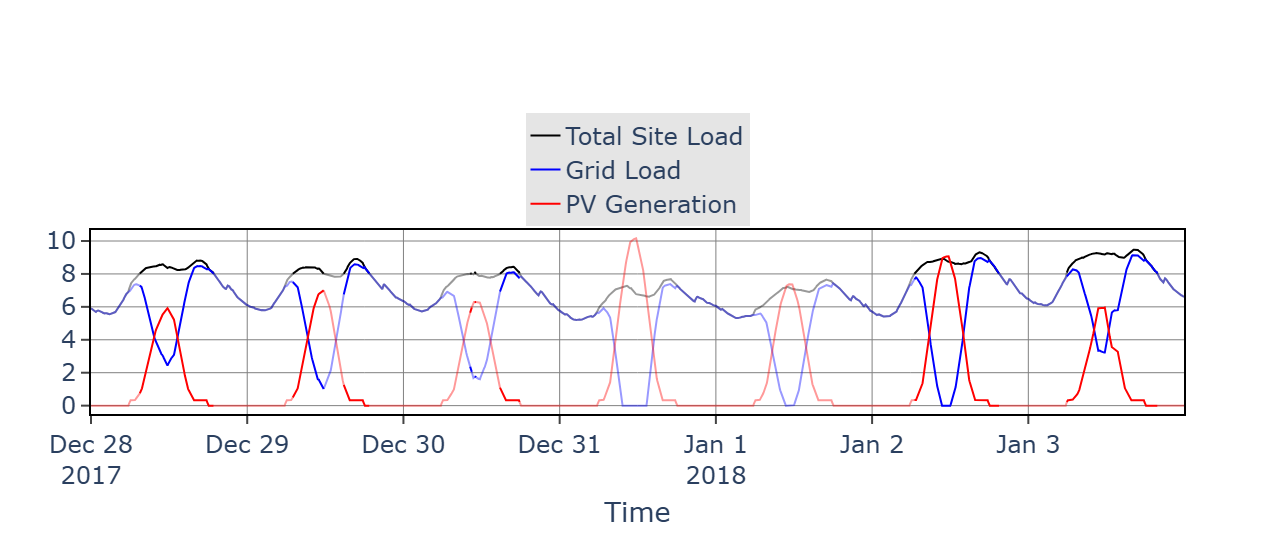